In [1]:
# ========================= #
# Imports and configuration #
# ========================= #
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.cloud import storage
from dotenv import load_dotenv

# Load environment variables
load_dotenv()

# Add src to path for utils
sys.path.append('../../src')
from utils import set_seed, SEED
set_seed()

# GCP configuration
PROJECT_ID = "project-5c89dcac-34cb-453d-bd7"
BUCKET_RAW = "sinodio-raw-data"

# Dataset paths in GCP bucket
DATASET_PATHS = {
    "superset": "spanish_hate_superset/train.csv",
    "detoxis": "detoxis/train.csv",
    "haha": "haha/train.csv"
}

print("Setup complete.")

Setup complete.


In [2]:
# ====================== #
# Load datasets from GCP #
# ====================== #
def load_csv_from_bucket(bucket_name, blob_path):
    """Load a CSV file from a GCP bucket into a pandas DataFrame."""
    client = storage.Client(project=PROJECT_ID) # Connect with GCP Cloud Storage using authenticated credentials
    bucket = client.bucket(bucket_name)         # Point to the bucket where the files are stored in GCP
    blob = bucket.blob(blob_path)               # Point to the specific BLOB (Binary Large OBject), ie the file.
    
    # Download to temporary file and load
    temp_path = f"/tmp/{blob_path.replace('/', '_')}"
    blob.download_to_filename(temp_path)        # Download file to temp file locally
    df = pd.read_csv(temp_path)                 # Load to Pandas df
    os.remove(temp_path)                        # Remove temp file
    
    return df

# Load all datasets into a dictionary
# (key = name of dataset ; value = corresponding df)
datasets = {}
for name, path in DATASET_PATHS.items():
    print(f"Loading {name}...")
    datasets[name] = load_csv_from_bucket(BUCKET_RAW, path)
    print(f"Loaded {name}: {datasets[name].shape[0]} rows, {datasets[name].shape[1]} columns")

print("\nAll datasets loaded successfully.")

Loading superset...
Loaded superset: 29855 rows, 7 columns
Loading detoxis...
Loaded detoxis: 3463 rows, 3 columns
Loading haha...
Loaded haha: 24000 rows, 3 columns

All datasets loaded successfully.


In [3]:
# ========================================= #
# Inspect structure, columns and data types #
# ========================================= #
for name, df in datasets.items(): #looping through each dataset
    print(f"\n{'='*50}")
    print(f"Dataset: {name.upper()}")
    print(f"{'='*50}")
    print(f"Shape: {df.shape}")
    print(f"\nColumns and data types:")
    print(df.dtypes)
    print(f"\nFirst 3 rows:")
    display(df.head(3))
    print(f"\nBasic statistics:")
    display(df.describe(include='all'))


Dataset: SUPERSET
Shape: (29855, 7)

Columns and data types:
text                                str
labels                          float64
source                              str
dataset                             str
nb_annotators                     int64
tweet_id                        float64
post_author_country_location        str
dtype: object

First 3 rows:


,text,labels,source,dataset,nb_annotators,tweet_id,post_author_country_location
0,Eran tan pero tan feministas que invisibilizab...,0.0,Twitter,chileno,3,1.401281e+18,unknown
1,@USER @USER @USER Me carga en lo q se convirti...,0.0,Twitter,chileno,3,1.402708e+18,Chile
2,", ¿Sabrán las femiorcas como @USER y todo el f...",1.0,Twitter,chileno,3,1.402623e+18,unknown



Basic statistics:


,text,labels,source,dataset,nb_annotators,tweet_id,post_author_country_location
count,29855,29855.000000,29551,29855,29855.00000,1.926600e+04,29855
unique,29657,NaN,1,6,NaN,NaN,93
top,"El lichi, culpable de la muerte de cientos de ...",NaN,Twitter,chileno,NaN,NaN,unknown
freq,13,NaN,29551,9500,NaN,NaN,16582
mean,NaN,0.243343,NaN,NaN,3.21112,1.194185e+18,NaN
std,NaN,0.429108,NaN,NaN,0.40811,2.414900e+17,NaN
min,NaN,0.000000,NaN,NaN,3.00000,1.617847e+17,NaN
25%,NaN,0.000000,NaN,NaN,3.00000,9.384001e+17,NaN
50%,NaN,0.000000,NaN,NaN,3.00000,1.237405e+18,NaN
75%,NaN,0.000000,NaN,NaN,3.00000,1.403123e+18,NaN



Dataset: DETOXIS
Shape: (3463, 3)

Columns and data types:
text          str
label       int64
language      str
dtype: object

First 3 rows:


...

,text,label,language
count,3463,3463.000000,3463
unique,3445,NaN,1
top,Los mas valientes,NaN,spanish
freq,3,NaN,3463
mean,NaN,0.331216,NaN
std,NaN,0.470718,NaN
min,NaN,0.000000,NaN
25%,NaN,0.000000,NaN
50%,NaN,0.000000,NaN
75%,NaN,1.000000,NaN



Dataset: HAHA
Shape: (24000, 3)

Columns and data types:
text          str
label       int64
language      str
dtype: object

First 3 rows:


,text,label,language
0,Niveles de retraso mental: \n\n— Bajo.\n— Medi...,1,spanish
1,"—Vamos Luke desenfunda tu sable, demuestra tu ...",1,spanish
2,"- ¿Te ofrezco algo?, ¿Agua, café, mi corazón, ...",1,spanish



Basic statistics:


,text,label,language
count,24000,24000.000000,24000
unique,24000,NaN,1
top,Niveles de retraso mental: \n\n— Bajo.\n— Medi...,NaN,spanish
freq,1,NaN,24000
mean,NaN,0.385542,NaN
std,NaN,0.486733,NaN
min,NaN,0.000000,NaN
25%,NaN,0.000000,NaN
50%,NaN,0.000000,NaN
75%,NaN,1.000000,NaN


**Note on some of the "NaN" displayed in the statistics:**

`df.describe(include='all')` automatically computes and displays all of the above statistics in one go:
* For numeric columns it gives: count, mean, std, min, 25%, 50% (median), 75%, max.
* For categorical/object columns it gives: count (total number of values), unique (number of unique values), top (most frequent value), freq (frequency of the most frequent value).

Note in the results above that:

* **numerical fields** contain "NaN" in the statistical measures that only apply to categorical fields (unique, top, freq)
* **categorical fields** contain "NaN" in the statistical measures that only apply to numerical fields (mean,std, min, 25%, 50%, 75%, max)

These are just artifacts of pandas, they don't mean that there is data missing. The null values check will be computed further down.

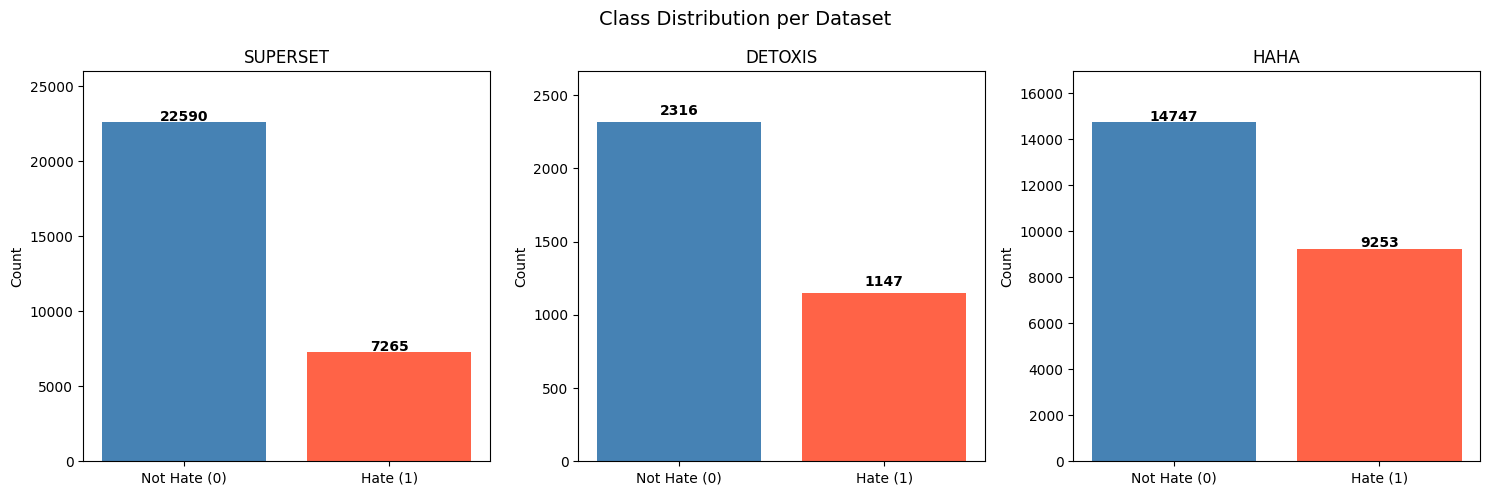

Plot saved.


In [4]:
# ============================== #
# Class distribution per dataset #
# ============================== #
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Class Distribution per Dataset', fontsize=14)

label_cols = {'superset': 'labels', 'detoxis': 'label', 'haha': 'label'}

for idx, (name, df) in enumerate(datasets.items()):
    label_col = label_cols[name]
    counts = df[label_col].value_counts().sort_index()
    axes[idx].bar(['Not Hate (0)', 'Hate (1)'], counts.values,
                  color=['steelblue', 'tomato'])   # having some fun with other hues of blue and red :-)
    axes[idx].set_title(name.upper())
    axes[idx].set_ylabel('Count')
    axes[idx].set_ylim(0, max(counts.values) * 1.15)
    for i, v in enumerate(counts.values):
        axes[idx].text(i, v + 50, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('/tmp/class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved.")

**Comments on the class distribution per dataset:**

All three sets are imbalanced but in different degrees. HAHA is the most balanced, which makes sense since it was specifically constructed around humor that often contains offensive content. The superset is the most imbalanced, which is realistic since it contains real social media data where hate speech is genuinely a minority phenomenon.

* Superset: 22,590 vs 7,265 → approximately 76% / 24%
* DETOXIS: 2,316 vs 1,147 → approximately 67% / 33%
* HAHA: 14,747 vs 9,253 → approximately 61% / 39%


**Important implication:**

When merging the three datasets, the superset will dominate due to the much higher volume of rows. Thus the overall class distribution will be approximately 70/30%. Using class_weight='balanced' in the ML models will be an important measure, as well as monitoring macro F1 rather than micro accuracy.


SUPERSET — Text length statistics:
  Overall:  mean=129.3, median=113.0, max=559
  Not Hate: mean=132.7, median=116.0
  Hate:     mean=118.7, median=101.0

DETOXIS — Text length statistics:
  Overall:  mean=206.7, median=127.0, max=3270
  Not Hate: mean=199.3, median=120.0
  Hate:     mean=221.5, median=140.0

HAHA — Text length statistics:
  Overall:  mean=79.7, median=77.0, max=142
  Not Hate: mean=68.1, median=63.0
  Hate:     mean=98.2, median=101.0


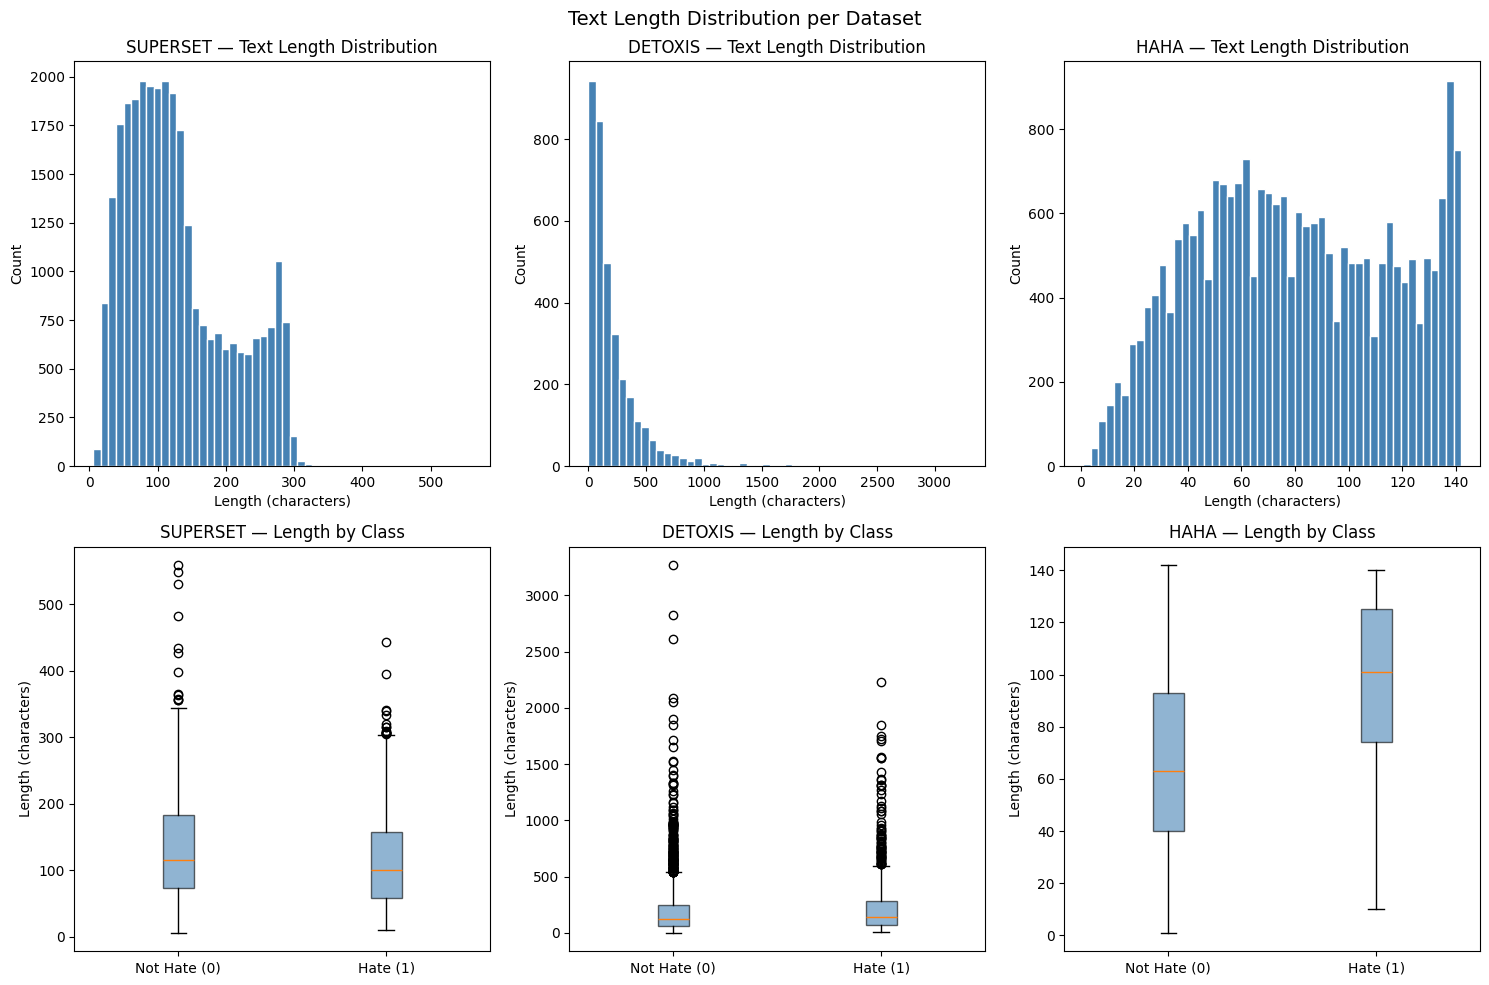


Plot saved.


In [5]:
# ======================== #
# Text length distribution #
# ======================== #
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Text Length Distribution per Dataset', fontsize=14)

label_cols = {'superset': 'labels', 'detoxis': 'label', 'haha': 'label'}

for idx, (name, df) in enumerate(datasets.items()):
    label_col = label_cols[name]

    # Add text length column (in characters)
    df['text_length'] = df['text'].str.len()

    # Top row: histogram of text length
    axes[0, idx].hist(df['text_length'], bins=50, color='steelblue', edgecolor='white')
    axes[0, idx].set_title(f'{name.upper()} — Text Length Distribution')
    axes[0, idx].set_xlabel('Length (characters)')
    axes[0, idx].set_ylabel('Count')

    # Bottom row: boxplot by class
    hate = df[df[label_col] == 1]['text_length']
    not_hate = df[df[label_col] == 0]['text_length']
    axes[1, idx].boxplot([not_hate, hate],
                         tick_labels=['Not Hate (0)', 'Hate (1)'],
                         patch_artist=True,
                         boxprops=dict(facecolor='steelblue', alpha=0.6))
    axes[1, idx].set_title(f'{name.upper()} — Length by Class')
    axes[1, idx].set_ylabel('Length (characters)')

    # Print summary statistics
    print(f"\n{name.upper()} — Text length statistics:")
    print(f"  Overall:  mean={df['text_length'].mean():.1f}, "
          f"median={df['text_length'].median():.1f}, "
          f"max={df['text_length'].max()}")
    print(f"  Not Hate: mean={not_hate.mean():.1f}, median={not_hate.median():.1f}")
    print(f"  Hate:     mean={hate.mean():.1f}, median={hate.median():.1f}")

plt.tight_layout()
plt.savefig('/tmp/text_length_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nPlot saved.")

**Comments on the plots:**

* Superset: Hate speech is slightly shorter than non-hate (mean 119 vs 133 characters). This was expected: in social media, hateful tweets tend to be direct and blunt, rather than elaborated. The distribution shows a main peak around 100-150 characters (typical tweet length) and a smaller peak around 280-320 characters.
  
* DETOXIS: Here hate speech is slightly longer than non-hate (mean 222 vs 199 characters, similar for the median). This makes sense given the source: since these are news article comments, not tweets, people writing toxic comments elaborate on their arguments, similar to what was discovered in the NLP module work with negative Amazon reviews. There are some extremely long outliers of up to 3270 characters. A truncation strategy similar to what was done in the NLP module will be applicable here as well.

* HAHA: The strongest difference of the three: hate speech is substantially longer than non-hate (mean 98 vs 68 characters, median 101 vs 63). This is interesting because HAHA is a humor dataset. Does offensive humor require more setup and context than neutral humor?

**Important implication:**

The three datasets have very different text lengths, which makes sense given their sources, but this means a truncation strategy will have to be implemented during preprocessing. DETOXIS in particular has extreme outliers that could cause issues during tokenization with XLM-RoBERTa (maximum input length of 512 tokens). A rough rule of thumb is that one token is approximately 4-5 characters in Spanish, so the DETOXIS maximum of 3270 characters corresponds to roughly 650-800 tokens, well above the 512 token limit.

In [6]:
# ============================ #
# Longest texts per dataset    #
# ============================ #

for name, df in datasets.items():
    print(f"\n{'='*60}")
    print(f"{name.upper()} — Longest text ({df['text_length'].max()} characters):")
    print(f"{'='*60}")
    longest_idx = df['text_length'].idxmax()
    print(df.loc[longest_idx, 'text'])


SUPERSET — Longest text (559 characters):
@USER @USER @USER @USER @USER @USER @USER @USER @USER @USER @USER @USER @USER @USER @USER @USER @USER @USER @USER @USER @USER @USER @USER @USER @USER @USER @USER @USER @USER @USER @USER @USER @USER @USER @USER @USER @USER @USER @USER @USER @USER @USER @USER @USER @USER @USER @USER @USER @USER la migración es argumento?\nYa tardabas !!\n.. si tan mal están y tan desnutrios están por que esos países tan prósperos no acogen y dan trabajo y riquezas a los migrantes?\n\n\nO simplemente los migrantes huyen de guerras y bloqueos que sufren de esos países. LINK

DETOXIS — Longest text (3270 characters):
en el primer enlace que aporta no dice nada de eso. De hecho pide lo que ya hizo el gobierno cuando desplegó a la UME. ¿Es el gobierno actual fascista por ello? TOdas juntas podrían convertirte en fascista si añadiera otros principios fundamentales de tal ideología, pero resulta que todas ellas, en mayor o menor medida, son aplicables a muchos otros pa

**Comments about longest texts in each dataset:**

* **Superset:** The longest text is almost entirely made up of @USER mentions (36 of them) followed by a short comment about immigration. While this is a Twitter/X artifact (the original dataset anonymized usernames by replacing them with @USER), it raises the question of whether the number of @USER mentions may be a significant feature in hate speech detection, as it could identify **harrassment**. Also, this means that there might be other texts that are longer, since here the high number of mentions inflates the character count artificially. During preprocessing, replacing all @USER tokens with a single @USER or removing them entirely and just keeping a count would be sensible.

* **DETOXIS:** The longest text at 3,270 characters is a genuine long-form comment from a news article, in this case a structured political argument about whether Vox is fascist. This is legitimate content but at 3,270 characters it is roughly 10 times longer than the median. It confirms that DETOXIS has a long tail of verbose comments that will need truncation before feeding into XLM-RoBERTa, which has a 512 token limit. How is the truncation should take place while minimizing the information loss is an important question.

* **HAHA:** The longest text at 142 characters contains what appears to be a reference to suicidal ideation followed by an ASCII art image. This raises two concerns worth noting: first, the ASCII art characters will be noise during tokenization and should be removed in preprocessing. Second, this content touches on self-harm, which is a reminder that hate speech datasets can contain sensitive content beyond hate speech itself — something to document in the ethical considerations section of the memoria, or even as an idea for potential extensions of this work.

In [8]:
# ========================== #
# Null values and duplicates #
# ========================== #

print("=" * 60)
print("NULL VALUES")
print("=" * 60)

for name, df in datasets.items():
    print(f"\n{name.upper()}:")
    print(df.isnull().sum())

print("\n" + "=" * 60)
print("EMPTY, WHITESPACE-ONLY or VERY SHORT VALUES")
print("=" * 60)

for name, df in datasets.items():
    label_col = 'labels' if name == 'superset' else 'label'
    
    # Check for empty or whitespace-only strings
    empty = (df['text'].str.strip() == '').sum()
    very_short = (df['text'].str.len() < 3).sum()
    
    print(f"\n{name.upper()}:")
    print(f"  Empty or whitespace-only texts: {empty}")
    print(f"  Texts shorter than 3 characters: {very_short}")
    
print("\n" + "=" * 60)
print("EXACT DUPLICATES (full row)")
print("=" * 60)

for name, df in datasets.items():
    n_dupes = df.duplicated().sum()
    print(f"\n{name.upper()}: {n_dupes} duplicate rows")

print("\n" + "=" * 60)
print("TEXT DUPLICATES (same text, possibly different label)")
print("=" * 60)

for name, df in datasets.items():
    n_text_dupes = df['text'].duplicated().sum()
    print(f"\n{name.upper()}: {n_text_dupes} duplicate texts")
    if n_text_dupes > 0:
        # Show cases where same text has different labels
        label_col = 'labels' if name == 'superset' else 'label'
        text_label_dupes = df[df['text'].duplicated(keep=False)].groupby('text')[label_col].nunique()
        conflicting = text_label_dupes[text_label_dupes > 1]
        print(f"  Of which {len(conflicting)} have conflicting labels (same text, different class)")

print("\n" + "=" * 60)
print("CROSS-DATASET DUPLICATES")
print("=" * 60)

# Normalize text for comparison
def normalize_text(text):
    """Lowercase, remove punctuation and extra spaces."""
    import re
    text = text.lower().strip()
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\s+', ' ', text)
    return text

superset_texts = set(datasets['superset']['text'].apply(normalize_text))
detoxis_texts  = set(datasets['detoxis']['text'].apply(normalize_text))
haha_texts     = set(datasets['haha']['text'].apply(normalize_text))

print(f"\nTexts in DETOXIS also in SUPERSET: {len(detoxis_texts & superset_texts)}")
print(f"Texts in HAHA also in SUPERSET:    {len(haha_texts & superset_texts)}")
print(f"Texts in DETOXIS also in HAHA:     {len(detoxis_texts & haha_texts)}")

NULL VALUES

SUPERSET:
text                                0
labels                              0
source                            304
dataset                             0
nb_annotators                       0
tweet_id                        10589
post_author_country_location        0
text_length                         0
dtype: int64

DETOXIS:
text           0
label          0
language       0
text_length    0
dtype: int64

HAHA:
text           0
label          0
language       0
text_length    0
dtype: int64

EMPTY, WHITESPACE-ONLY or VERY SHORT VALUES

SUPERSET:
  Empty or whitespace-only texts: 0
  Texts shorter than 3 characters: 0

DETOXIS:
  Empty or whitespace-only texts: 0
  Texts shorter than 3 characters: 7

HAHA:
  Empty or whitespace-only texts: 0
  Texts shorter than 3 characters: 2

EXACT DUPLICATES (full row)

SUPERSET: 87 duplicate rows

DETOXIS: 17 duplicate rows

HAHA: 0 duplicate rows

TEXT DUPLICATES (same text, possibly different label)

SUPERSET: 198 duplicate

In [9]:
# ======================== #
# Inspect very short texts #
# ======================== #

for name, df in datasets.items():
    label_col = 'labels' if name == 'superset' else 'label'
    very_short = df[df['text'].str.len() < 3]
    if len(very_short) > 0:
        print(f"\n{name.upper()} — Texts shorter than 3 characters:")
        print(very_short[['text', label_col]])


DETOXIS — Texts shorter than 3 characters:
     text  label
977     X      0
978     V      0
1638   xD      0
2123   ok      0
3443   +1      0
3444   +1      0
3451   +1      0

HAHA — Texts shorter than 3 characters:
      text  label
11921   :(      0
19994    .      0


**Comments on very short texts:**

These are all non-hate (label 0) and are all meaningless as text for classification purposes:

* X, V: single letters, likely data entry errors
* xD: an emoticon
* ok: a single word with no semantic value for hate speech detection
* +1: a vote or agreement signal, appears three times
* :(: an emoticon
* .: a single punctuation mark

None of these carry useful information for the classifier and can be dropped during preprocessing. The fact that they are all label 0 is reassuring since dropping them will not affect the minority hate class.

PART 1: @USER COUNT BY CLASS (SUPERSET)

Not Hate — mean @USER count: 0.89, median: 1.0, max: 50
Hate     — mean @USER count: 0.97, median: 1.0, max: 32


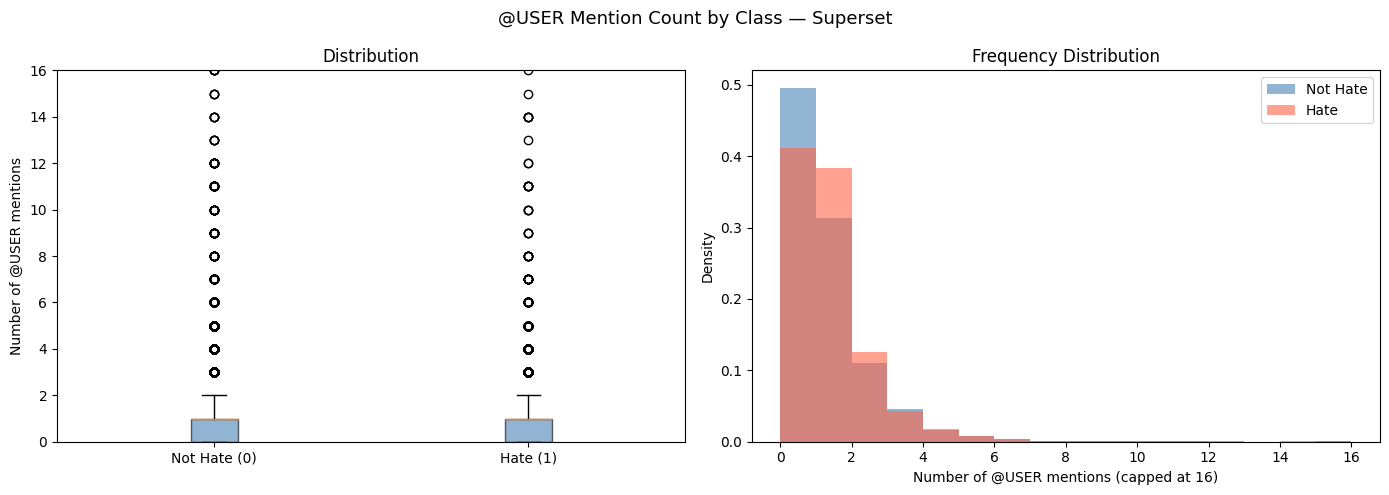


PART 2: TOP-20 TERMS — HATE VS NON-HATE


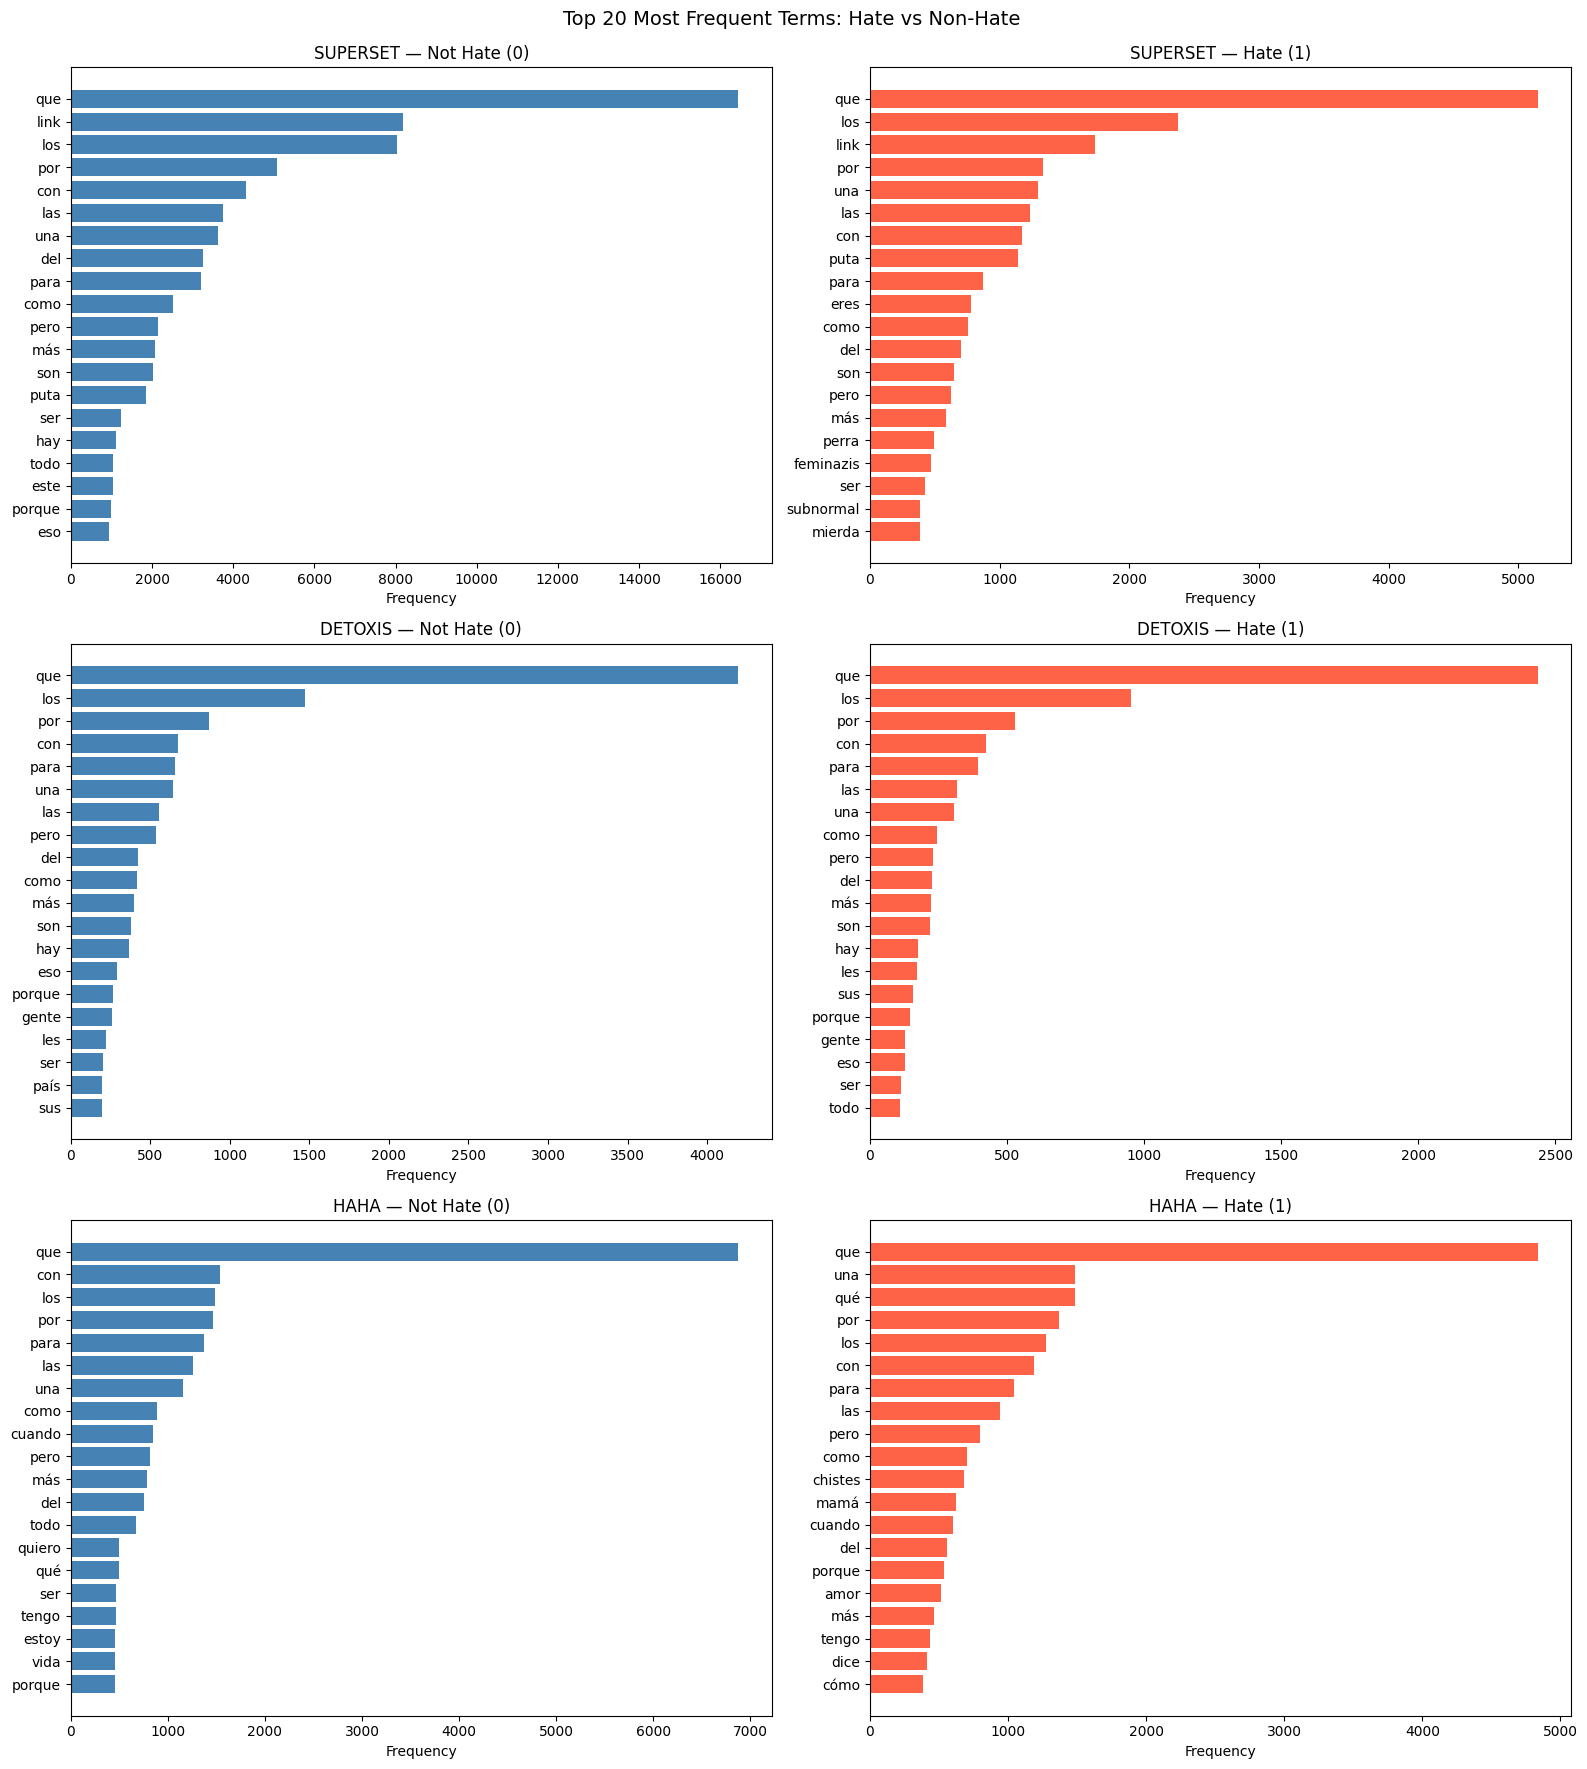


PART 3: EDA SUMMARY


,Dataset,Total examples,Hate (%),Median length,Max length,Null values,Exact duplicates,Text duplicates,Conflicting labels
0,Superset,29855,24.3,113,559,"source, tweet_id",87,198,5
1,DETOXIS,3463,33.1,127,3270,None,17,18,1
2,HAHA,24000,38.6,77,142,None,0,0,0


In [13]:
import re
from collections import Counter

# ============================== #
# Helper: normalize and tokenize #
# ============================== #
def get_tokens(texts, remove_user=True, min_length=3):
    """
    Tokenize a series of texts, removing @USER, URLs,
    punctuation and short tokens.
    """
    tokens = []
    for text in texts:
        if remove_user:
            text = re.sub(r'@USER', '', text)
        text = re.sub(r'http\S+', '', text)        # remove URLs
        text = re.sub(r'[^\w\s]', '', text)        # remove punctuation
        text = text.lower()
        tokens.extend([t for t in text.split() 
                       if len(t) >= min_length 
                       and not t.isdigit()])
    return tokens

# ============================ #
# Part 1: @USER count by class #
#         (Superset only)      #
# ============================ #
print("=" * 60)
print("PART 1: @USER COUNT BY CLASS (SUPERSET)")
print("=" * 60)
cap = 16  #cap for readability

df_sup = datasets['superset'].copy()
df_sup['user_count'] = df_sup['text'].str.count('@USER')

hate_users    = df_sup[df_sup['labels'] == 1]['user_count']
nothate_users = df_sup[df_sup['labels'] == 0]['user_count']

print(f"\nNot Hate — mean @USER count: {nothate_users.mean():.2f}, "
      f"median: {nothate_users.median():.1f}, "
      f"max: {nothate_users.max()}")
print(f"Hate     — mean @USER count: {hate_users.mean():.2f}, "
      f"median: {hate_users.median():.1f}, "
      f"max: {hate_users.max()}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('@USER Mention Count by Class — Superset', fontsize=13)

axes[0].boxplot([nothate_users, hate_users],
                tick_labels=['Not Hate (0)', 'Hate (1)'],
                patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6))
axes[0].set_ylabel('Number of @USER mentions')
axes[0].set_title('Distribution')
axes[0].set_ylim(0, cap)

bins = range(0, cap+1)
axes[1].hist(nothate_users.clip(upper=cap), bins=bins,
             alpha=0.6, color='steelblue', label='Not Hate', density=True)
axes[1].hist(hate_users.clip(upper=cap), bins=bins,
             alpha=0.6, color='tomato', label='Hate', density=True)
axes[1].set_xlabel(f'Number of @USER mentions (capped at {cap})')
axes[1].set_ylabel('Density')
axes[1].set_title('Frequency Distribution')
axes[1].legend()

plt.tight_layout()
plt.savefig('/tmp/user_count_by_class.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================= #
# Part 2: Top-20 terms by class #
# ============================= #
print("\n" + "=" * 60)
print("PART 2: TOP-20 TERMS — HATE VS NON-HATE")
print("=" * 60)

label_cols = {'superset': 'labels', 'detoxis': 'label', 'haha': 'label'}

fig, axes = plt.subplots(3, 2, figsize=(16, 18))
fig.suptitle('Top 20 Most Frequent Terms: Hate vs Non-Hate \n', fontsize=14)

for row_idx, (name, df) in enumerate(datasets.items()):
    label_col = label_cols[name]

    hate_tokens    = get_tokens(df[df[label_col] == 1]['text'])
    nothate_tokens = get_tokens(df[df[label_col] == 0]['text'])

    hate_top20    = Counter(hate_tokens).most_common(20)
    nothate_top20 = Counter(nothate_tokens).most_common(20)

    # Not hate
    words, freqs = zip(*reversed(nothate_top20))
    axes[row_idx, 0].barh(words, freqs, color='steelblue')
    axes[row_idx, 0].set_title(f'{name.upper()} — Not Hate (0)')
    axes[row_idx, 0].set_xlabel('Frequency')

    # Hate
    words, freqs = zip(*reversed(hate_top20))
    axes[row_idx, 1].barh(words, freqs, color='tomato')
    axes[row_idx, 1].set_title(f'{name.upper()} — Hate (1)')
    axes[row_idx, 1].set_xlabel('Frequency')

plt.tight_layout()
plt.savefig('/tmp/top20_terms_by_class.png', dpi=150, bbox_inches='tight')
plt.show()

# ========================= #
# Part 3: EDA Summary table #
# ========================= #
print("\n" + "=" * 60)
print("PART 3: EDA SUMMARY")
print("=" * 60)

summary = {
    'Dataset':            ['Superset', 'DETOXIS', 'HAHA'],
    'Total examples':     [29855, 3463, 24000],
    'Hate (%)':           [round(100*7265/29855,1),
                           round(100*1147/3463,1),
                           round(100*9253/24000,1)],
    'Median length':      [113, 127, 77],
    'Max length':         [559, 3270, 142],
    'Null values':        ['source, tweet_id', 'None', 'None'],
    'Exact duplicates':   [87, 17, 0],
    'Text duplicates':    [198, 18, 0],
    'Conflicting labels': [5, 1, 0],
}

summary_df = pd.DataFrame(summary)
display(summary_df)

**Comments on the above results:**

* The @USER count does not seem to be much of a discriminating feature. Both classes have essentially the same median (1.0) and very similar means (0.89 vs 0.97). While mass-mentioning does exist (max 50 for non-hate, max 32 for hate), it is rare enough in both classes and does not distinguish them systematically. Harassment patterns are likely present in the content of the text more than its structural features like mention counts. This reinforces the choice of XLM-RoBERTa over simpler feature-based approaches; I expect that using a transformer, thanks to the "attention mechanism", will help capture contextual relationships between words simultaneously across the entire input text, allowing it to detect subtle patterns of hate speech that structural metadata cannot.

* The vast majority of most frequent words are dominated by stopwords that appear in both classes, making it impossible to see what truly distinguishes hate from non-hate speech. However, there are already some interesting signals visible even in this unfiltered list: "puta" appears in both classes but ranks 8th in hate vs 14th in non-hate; "perra", "feminazis", "subnormal", "mierda" (classic misogynistic and derogatory terms) are very frequent only in the hate class; "chistes", "mamá", "amor" appear in the HAHA hate class because offensive humor often uses family and affection terms ironically.

**Plan for the stopword-filtered version:**
The get_tokens function will be extended to also remove:

* Spanish stopwords from spaCy (es_core_news_sm)
* Twitter artifacts: "link", "@USER" (already handled), "rt"
* Single characters and digits


SUPERSET — Top 10 filtered terms:
  Not Hate: ['puta', 'mujer', 'mujeres', 'ctm', 'años', 'gente', 'chilenos', 'país', 'greta', 'chile']
  Hate:     ['puta', 'perra', 'feminazis', 'subnormal', 'mierda', 'callate', 'feminazi', 'cállate', 'zorra', 'inmigrantes']

DETOXIS — Top 10 filtered terms:
  Not Hate: ['gente', 'país', 'españa', 'problema', 'años', 'inmigrantes', 'vida', 'cosas', 'españoles', 'delincuentes']
  Hate:     ['gente', 'país', 'españa', 'vida', 'mierda', 'inmigrantes', 'mejores', 'casa', 'españoles', 'años']

HAHA — Top 10 filtered terms:
  Not Hate: ['quiero', 'vida', 'alguien', 'gente', 'cosas', 'ganas', 'dormir', 'amor', 'feliz', 'guau']
  Hate:     ['chistes', 'mamá', 'amor', 'hijo', 'vida', 'mujer', 'papá', 'chiste', 'casa', 'quiero']


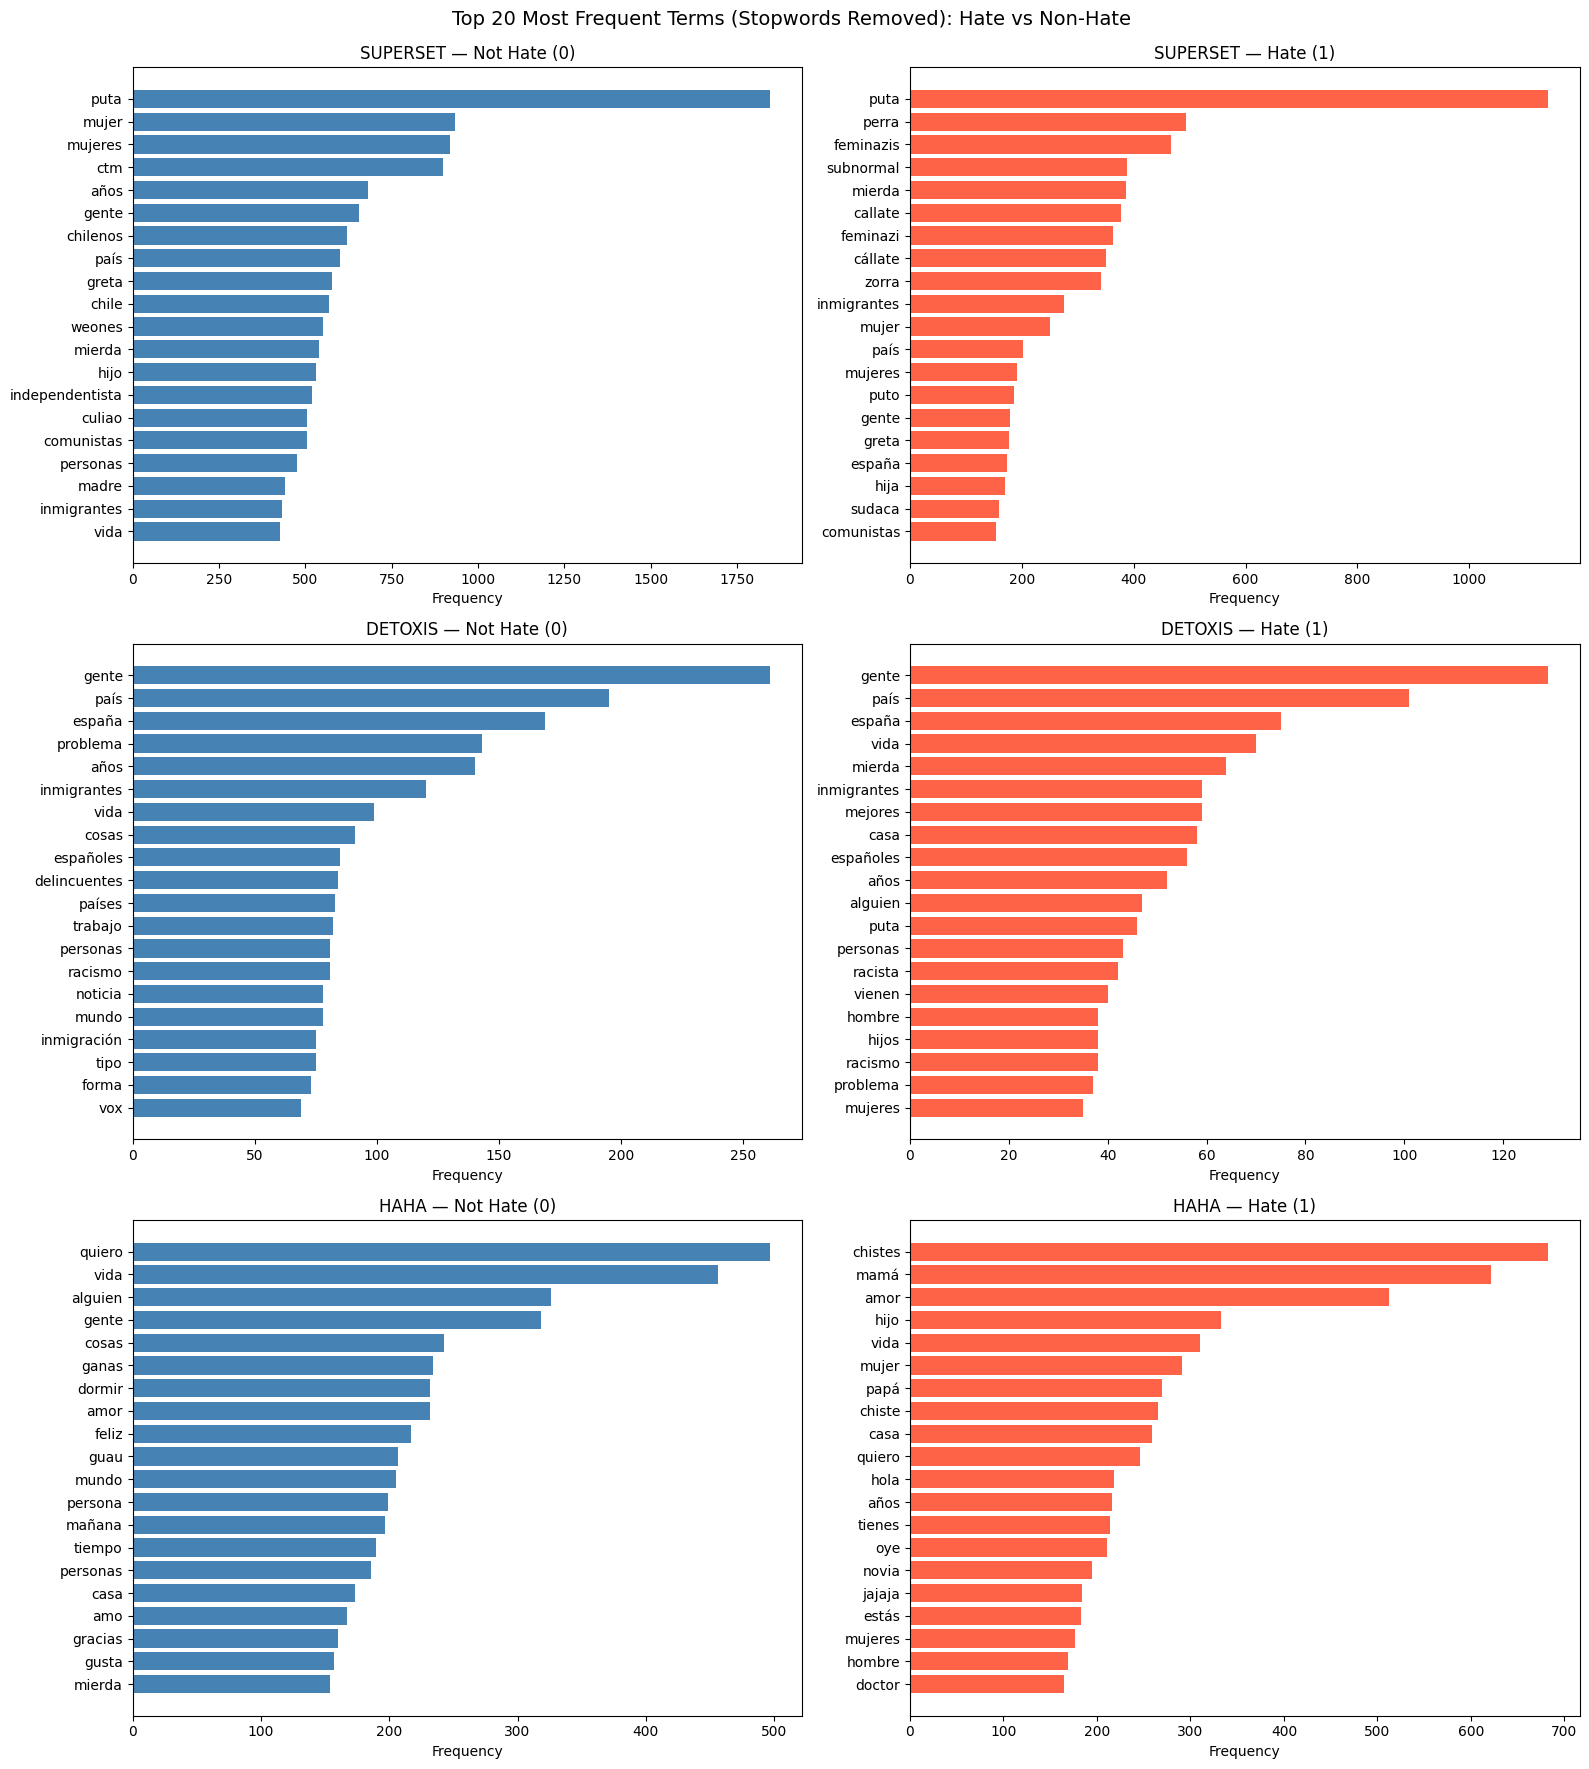

In [14]:
import re
import spacy
from collections import Counter

# Load Spanish spaCy model
nlp_es = spacy.load('es_core_news_sm')

# Spanish stopwords from spaCy
spanish_stopwords = nlp_es.Defaults.stop_words

# Additional Twitter/dataset artifacts to remove
extra_stopwords = {'link', 'rt', 'user', 'http', 'https', 'amp', 'via'}

all_stopwords = spanish_stopwords | extra_stopwords

# =============================== #
# Helper: normalize and tokenize  #
# with stopword removal           #
# =============================== #
def get_tokens_filtered(texts, min_length=3):
    """
    Tokenize a series of texts, removing:
    - @USER tokens and URLs
    - punctuation and digits
    - Spanish stopwords
    - Twitter artifacts
    - tokens shorter than min_length
    """
    tokens = []
    for text in texts:
        text = re.sub(r'@USER', '', text)          # remove @USER
        text = re.sub(r'http\S+', '', text)        # remove URLs
        text = re.sub(r'[^\w\s]', '', text)        # remove punctuation
        text = re.sub(r'\d+', '', text)            # remove digits
        text = text.lower().strip()
        tokens.extend([
            t for t in text.split()
            if len(t) >= min_length
            and t not in all_stopwords
        ])
    return tokens

# =============================== #
# Top-20 filtered terms by class  #
# =============================== #
label_cols = {'superset': 'labels', 'detoxis': 'label', 'haha': 'label'}

fig, axes = plt.subplots(3, 2, figsize=(16, 18))
fig.suptitle('Top 20 Most Frequent Terms (Stopwords Removed): Hate vs Non-Hate \n',
             fontsize=14)

for row_idx, (name, df) in enumerate(datasets.items()):
    label_col = label_cols[name]

    hate_tokens    = get_tokens_filtered(df[df[label_col] == 1]['text'])
    nothate_tokens = get_tokens_filtered(df[df[label_col] == 0]['text'])

    hate_top20    = Counter(hate_tokens).most_common(20)
    nothate_top20 = Counter(nothate_tokens).most_common(20)

    # Not hate
    words, freqs = zip(*reversed(nothate_top20))
    axes[row_idx, 0].barh(words, freqs, color='steelblue')
    axes[row_idx, 0].set_title(f'{name.upper()} — Not Hate (0)')
    axes[row_idx, 0].set_xlabel('Frequency')

    # Hate
    words, freqs = zip(*reversed(hate_top20))
    axes[row_idx, 1].barh(words, freqs, color='tomato')
    axes[row_idx, 1].set_title(f'{name.upper()} — Hate (1)')
    axes[row_idx, 1].set_xlabel('Frequency')

    # Print top 10 for quick reference
    print(f"\n{name.upper()} — Top 10 filtered terms:")
    print(f"  Not Hate: {[w for w,_ in nothate_top20[:10]]}")
    print(f"  Hate:     {[w for w,_ in hate_top20[:10]]}")

plt.tight_layout()
plt.savefig('/tmp/top20_terms_filtered.png', dpi=150, bbox_inches='tight')
plt.show()

**Comments on the above cell output:**

* **Superset (Twitter data):** The *hate class* is dominated by explicit slurs and misogynistic terms: "puta", "perra", "feminazis", "subnormal", "mierda", "callate", "zorra". The presence of both "feminazi" and its plural form "feminazis" is noteworthy because together they would be in second place, behind "puta" and ahead of "perra". Lemmatization (which will be applied in preprocessing) should take care of these cases, though with neologisms or words that may not be in the dictionary like "feminazi", lemmatization may not be handled correctly. Fortunately, RoBERTa is less affected by this limitation since it learns contextual representations rather than relying on dictionary lookups. The *non-hate class* is more interesting than expected, as Chilean Spanish profanity used in casual discourse gets picked up too, with words like "puta", "ctm" (=conchetumadre), "weones" (=huevones), "culiao" (=culiado). This confirms the strong Latin American bias of this dataset (Chile appears explicitly) and reinforces the importance of including the dataset DETOXIS, which is a compilation of comments only from Spain. Finally, the term "independentista" in the non-hate class is notable and suggests Catalan/Basque independence-related content that is not necessarily hateful.

+ **DETOXIS (News comments):** Both classes share many high-frequency terms: "gente", "país", "españa", "inmigrantes". This makes sense given that all DETOXIS comments are about immigration. The *hate class* distinguishes itself with "mierda", "racista", "racismo", "hombre", "mujeres" appearing more prominently, while the *non-hate class* has more analytical vocabulary: "problema", "cosas", "trabajo", "mundo", "forma". Interestingly, "vox" appears in the non-hate class; could it be people discussing Vox in a factual rather than inciting way?

* **HAHA — Humor dataset:** This is the most fascinating result. The *non-hate class* reads like everyday conversational Spanish: "quiero", "vida", "alguien", "gente", "feliz", "dormir", "amor", "gracias". The *hate class* tells a completely different story: "chistes", "mamá", "amor", "hijo", "papá", "chiste", "novia", "jajaja". This confirms that offensive humor in this dataset is structured around family relationships and joke setups; "jajaja" and "chiste"/"chistes" are explicit indicators of the humor framing through which hate is vehiculated. 


**Implication for the model:** the three datasets have very different vocabulary profiles for hate speech: explicit slurs in the superset, xenophobic discourse in DETOXIS, and humor-framed content in HAHA. A model trained only on one dataset would likely fail on the others. This heterogeneity is actually a strength of combining all three, as it will force the model to learn more generalizable representations of hate speech rather than overfitting to a single register or target group.

In [15]:
import os

plot_files = [
    '/tmp/class_distribution.png',
    '/tmp/text_length_distribution.png',
    '/tmp/user_count_by_class.png',
    '/tmp/top20_terms_filtered.png'
]

for f in plot_files:
    exists = os.path.exists(f)
    print(f"{f}: {'✓ exists' if exists else '✗ missing — needs regenerating'}")

/tmp/class_distribution.png: ✓ exists
/tmp/text_length_distribution.png: ✓ exists
/tmp/user_count_by_class.png: ✓ exists
/tmp/top20_terms_filtered.png: ✓ exists


In [16]:
import shutil

# Create a folder for EDA exports
os.makedirs('reports/eda_figures', exist_ok=True)

for f in plot_files:
    filename = os.path.basename(f)
    dest = f'reports/eda_figures/{filename}'
    shutil.copy(f, dest)
    print(f"Copied {filename} to reports/eda_figures/")

Copied class_distribution.png to reports/eda_figures/
Copied text_length_distribution.png to reports/eda_figures/
Copied user_count_by_class.png to reports/eda_figures/
Copied top20_terms_filtered.png to reports/eda_figures/
